In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:405"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def getRgs(systems,datasets,selection_strings):
    allrgs=[]
    rgs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrgs=[]
        for j in range(len(datasets[i])):
            rg=[]
            for ts in systems[i][j].trajectory: 
                rg.append((systems[i][j].trajectory.time, systems[i][j].select_atoms(selection_strings[i][j]).radius_of_gyration())[1])
            subrgs.append(rg)
        allrgs.append(subrgs)

    return allrgs




In [4]:
v1rgs = getRgs(systems,v1s,v1strings)

systemrgs_v1=[]
for i in range(len(v1rgs)):
    trjrgs_v1=[]
    for j in range(len(v1rgs[i])):
        trjrgs_v1.append(mean(v1rgs[i][j]))
    systemrgs_v1.append(trjrgs_v1)

In [5]:
v2rgs = getRgs(systems,v2s,v2strings)

systemrgs_v2=[]
for i in range(len(v2rgs)):
    trjrgs_v2=[]
    for j in range(len(v2rgs[i])):
        trjrgs_v2.append(mean(v2rgs[i][j]))
    systemrgs_v2.append(trjrgs_v2)

In [6]:
v3rgs = getRgs(systems,v3s,v3strings)

systemrgs_v3=[]
for i in range(len(v3rgs)):
    trjrgs_v3=[]
    for j in range(len(v3rgs[i])):
        trjrgs_v3.append(mean(v3rgs[i][j]))
    systemrgs_v3.append(trjrgs_v3)

In [52]:
array(v3rgs).shape

(3, 9, 4001)

In [16]:
reshaped_v1_rg=array(v1rgs).reshape(3,-1)
reshaped_v2_rg=array(v2rgs).reshape(3,-1)
reshaped_v3_rg=array(v3rgs).reshape(3,-1)

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


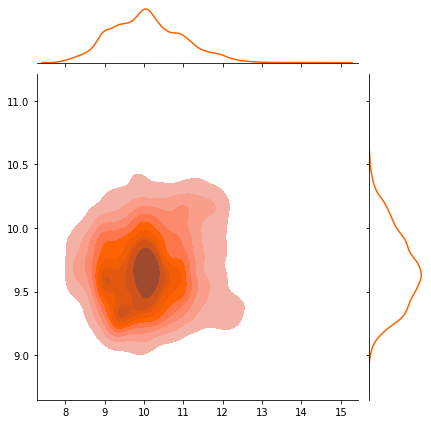

In [25]:
sns.jointplot(reshaped_v1_rg[0],reshaped_v2_rg[0],kind = "kde",shade = True,color=colourScheme[0])

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


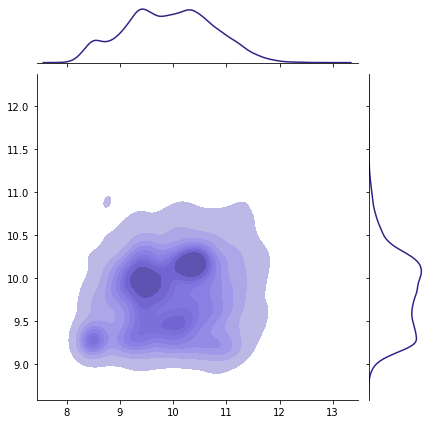

In [24]:
sns.jointplot(reshaped_v1_rg[1],reshaped_v2_rg[1],kind = "kde",shade = True,color=colourScheme[1])

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


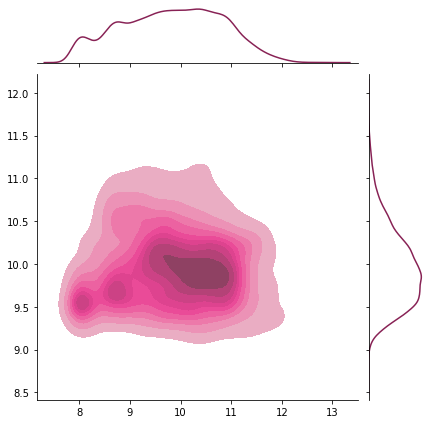

In [22]:
sns.jointplot(reshaped_v1_rg[2],reshaped_v2_rg[2],kind = "kde",shade = True,color=colourScheme[2])

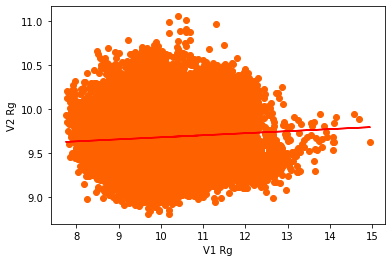

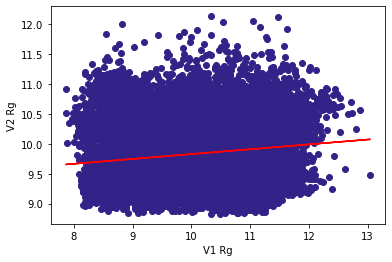

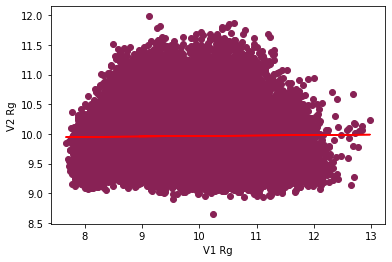

In [48]:
linearfits=[]

linearfits.append(polyfit(reshaped_v1_rg[0],reshaped_v2_rg[0],deg = 1))
linearfits.append(polyfit(reshaped_v1_rg[1],reshaped_v2_rg[1],deg = 1))
linearfits.append(polyfit(reshaped_v1_rg[2],reshaped_v2_rg[2],deg = 1))

scatter(reshaped_v1_rg[0],reshaped_v2_rg[0],color = colourScheme[0])
plot(reshaped_v1_rg[0],linearfits[0][1] + linearfits[0][0]*reshaped_v1_rg[0],color = 'red')

xlabel("V1 Rg")
ylabel("V2 Rg")
show()

scatter(reshaped_v1_rg[1],reshaped_v2_rg[1],color = colourScheme[1])

plot(reshaped_v1_rg[1],linearfits[1][1] + linearfits[1][0]*reshaped_v1_rg[1],color = 'red')
xlabel("V1 Rg")
ylabel("V2 Rg")
show()


scatter(reshaped_v1_rg[2],reshaped_v2_rg[2],color = colourScheme[2])

plot(reshaped_v1_rg[2],linearfits[2][1] + linearfits[2][0]*reshaped_v1_rg[2],color = 'red')
xlabel("V1 Rg")
ylabel("V2 Rg")
show()

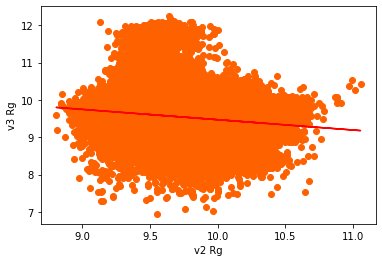

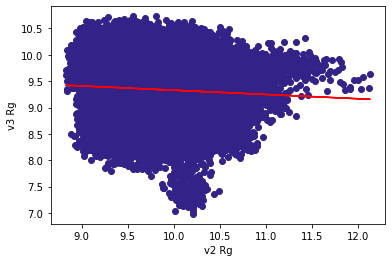

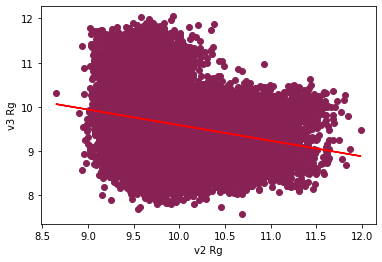

In [51]:
linearfits=[]

linearfits.append(polyfit(reshaped_v2_rg[0],reshaped_v3_rg[0],deg = 1))
linearfits.append(polyfit(reshaped_v2_rg[1],reshaped_v3_rg[1],deg = 1))
linearfits.append(polyfit(reshaped_v2_rg[2],reshaped_v3_rg[2],deg = 1))

scatter(reshaped_v2_rg[0],reshaped_v3_rg[0],color = colourScheme[0])
plot(reshaped_v2_rg[0],linearfits[0][1] + linearfits[0][0]*reshaped_v2_rg[0],color = 'red')

xlabel("v2 Rg")
ylabel("v3 Rg")
show()

scatter(reshaped_v2_rg[1],reshaped_v3_rg[1],color = colourScheme[1])

plot(reshaped_v2_rg[1],linearfits[1][1] + linearfits[1][0]*reshaped_v2_rg[1],color = 'red')
xlabel("v2 Rg")
ylabel("v3 Rg")
show()


scatter(reshaped_v2_rg[2],reshaped_v3_rg[2],color = colourScheme[2])
plot(reshaped_v2_rg[2],linearfits[2][1] + linearfits[2][0]*reshaped_v2_rg[2],color = 'red')
xlabel("v2 Rg")
ylabel("v3 Rg")
show()

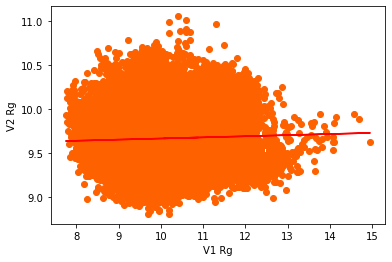

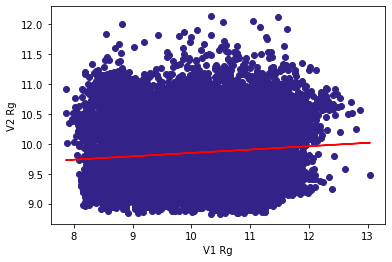

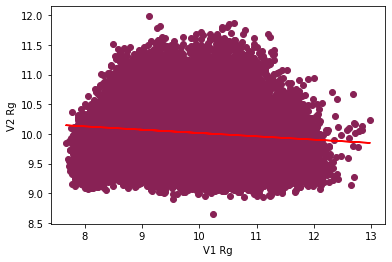

In [79]:
linearfits=[]


for i in range(len(v1rgs)):
    sub=[]
    for j in range(len(v1rgs[i])):
        sub.append(polyfit(array(v1rgs)[i][j],array(v2rgs)[i][j],deg = 1))
        
    linearfits.append(sub)
    

avg_fits = []
sem_fits = []
for i in range(len(linearfits)):
    avg_fits.append(mean(array(linearfits[i]),axis = 0))
    sem_fits.append(scipy.stats.sem(array(linearfits[i]),axis = 0))

    
    
scatter(reshaped_v1_rg[0],reshaped_v2_rg[0],color = colourScheme[0])
plot(reshaped_v1_rg[0],avg_fits[0][1] + avg_fits[0][0]*reshaped_v1_rg[0],color = 'red')

xlabel("V1 Rg")
ylabel("V2 Rg")
show()

scatter(reshaped_v1_rg[1],reshaped_v2_rg[1],color = colourScheme[1])

plot(reshaped_v1_rg[1],avg_fits[1][1] + avg_fits[1][0]*reshaped_v1_rg[1],color = 'red')
xlabel("V1 Rg")
ylabel("V2 Rg")
show()


scatter(reshaped_v1_rg[2],reshaped_v2_rg[2],color = colourScheme[2])

plot(reshaped_v1_rg[2],avg_fits[2][1] + avg_fits[2][0]*reshaped_v1_rg[2],color = 'red')
xlabel("V1 Rg")
ylabel("V2 Rg")
show()

In [78]:
linearfits[0][0]

array([0.07515062, 8.79386447])